# Submission Summary

| Item                              | Details                                                     |
| --------------------------------- | ----------------------------------------------------------- |
| **Group number**                  | 23                                                          |
| **Full name**                     | Ohiri Emmanuel Tochukwu                                       |
| **Dataset**                       | Adult Census Income                                         |
| **Depth track**                   | Classification Depth                                        |
| **Team members**                  | Odekunle Foyinsola Sultana, Balogun Saidat, Imoisili Deborah Osewe, Gabriel Emmanuel, Ibekwe Kosisochukwu Caleb, Hannah Oluwadolapo Williams, Madubuchibie Augustine Nwabueze, Tinuola Sanusi, Utibe-Abasi Abia Udoh, Ohiri Tochukwu Emmanuel, Edaferuake Blessing Uruamu, Adeniran Opeoluwa Christiana, Ademola Elizabeth, Badmus Abdulazeez Adebayo            |
| **Final model**                   | Random Forest, `class_weight="balanced"`, threshold = 0.34 |
| **Stratified dummy F1 / ROC AUC** | 23.98 / 50.01                                               |
| **Final model F1 / ROC AUC**      | 69.99 / 90.17                                               |
| **Leakage columns dropped**       | None found                                                  |
| **Full run time on Colab**        | 12.37 minutes                  |


In [1]:
# Importing all the things i'll need
# Core
import os
import numpy as np
import pandas as pd
import sqlite3
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading
import kagglehub

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, precision_recall_curve
)

%matplotlib inline

In [2]:
import time

notebook_start_time = time.time()

## Part 1. Data Foundation

#### 1. Load the dataset from Kaggle inside the notebook and push it into a SQLite database.


In [3]:
!pip install -q kagglehub

In [4]:
path = kagglehub.dataset_download("uciml/adult-census-income")

print("Dataset downloaded to:", path)


Using Colab cache for faster access to the 'adult-census-income' dataset.
Dataset downloaded to: /kaggle/input/adult-census-income


In [5]:
os.listdir(path)

['adult.csv']

In [6]:
df = pd.read_csv(os.path.join(path, "adult.csv"))
conn = sqlite3.connect("adult_income.db")
df.to_sql("adult_income", conn, index=False, if_exists="replace")

32561

In [7]:
# Checking to see if this ran correctly
pd.read_sql_query(
    "SELECT * FROM adult_income LIMIT 5;",
    conn
)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [8]:
# Another Check
pd.read_sql_query(
    "SELECT COUNT(*) AS total_rows FROM adult_income;",
    conn
)

,total_rows
0,32561


#### 2. Run at least three SQL queries that reveal something useful, each followed by a markdown cell explaining what you learned.


In [9]:
# 1.
pd.read_sql_query(
    """
    SELECT income, COUNT(*) AS count
    FROM adult_income
    GROUP BY income;
    """,
    conn
)

,income,count
0,<=50K,24720
1,>50K,7841


What I learnt: I noticed that a large percentage of the adult customers earn less than 50k, which means about 75.91% percent of the adults in this dataset are on the less-earning side of less than 50k. Meaning the income classes are not evenly distributed

In [10]:
#2.
pd.read_sql_query(
    """
    SELECT education, COUNT(*) AS count
    FROM adult_income
    GROUP BY education
    ORDER BY count DESC;
    """,
    conn
)

,education,count
0,HS-grad,10501
1,Some-college,7291
2,Bachelors,5355
3,Masters,1723
4,Assoc-voc,1382
5,11th,1175
6,Assoc-acdm,1067
7,10th,933
8,7th-8th,646
9,Prof-school,576


What I noticed: I found that HS-grad was the highest denomination of the records in this dataset with 10501 entries followed by Some-college which is 7291 and Bachelors with 5,355. While education levels such as Doctorate (413) and Preschool (51) represent a very small portion of the dataset. This tells us that the dataset contains adults with a wide range of educational backgrounds, although some are glaringly more than the others...

In [11]:
# 3
pd.read_sql_query(
    """
    SELECT education, income, COUNT(*) AS count
    FROM adult_income
    GROUP BY education, income
    ORDER BY education, count DESC;
    """,
    conn
)

,education,income,count
0,10th,<=50K,871
1,10th,>50K,62
2,11th,<=50K,1115
3,11th,>50K,60
4,12th,<=50K,400
5,12th,>50K,33
6,1st-4th,<=50K,162
7,1st-4th,>50K,6
8,5th-6th,<=50K,317
9,5th-6th,>50K,16


What I noticed: The result showed that the distribution of income varies across the different education levels we have. The lower education levels hae more people that are earning **less than or equal to 50k** than they have people earning **more than 50k**. While the higher education levels have more people earning **more than 50k**.E.g the Bachelors category has 2221 people earning **>50k** compared to 3134 earning **<=50k**

#### 3. Perform EDA: shape, types, missing values, target distribution, and three to five feature distributions.


In [12]:
df.shape  #Tells us the shape of the dataset returns it in the order of (number_rows, number_columns)

(32561, 15)

In [13]:
df.dtypes #reveals the data types we currently have

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


In [14]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [15]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [17]:
# 3. Missing values
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [18]:
(df == "?").sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


The `.isnull().sum()` summary shows no missing values. However, checking for the placeholder string "?" reveals it is used to represent missing data in several columns (e.g., workclass, occupation, native.country). I will convert "?" to NaN so these are properly recognized as missing values in the cleaning

In [19]:
# Checking skewness of the numeric columns before cleaning/scaling
df.select_dtypes(include=[np.number]).skew().sort_values(ascending=False)

,0
capital.gain,11.953848
capital.loss,4.594629
fnlwgt,1.446980
age,0.558743
hours.per.week,0.227643
education.num,-0.311676


In [20]:
df.duplicated().sum()

np.int64(24)

In [21]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
19622,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
20507,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
10307,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
22783,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
17456,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
22934,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
7615,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
32065,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
9269,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
14346,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K


In [22]:
# Target distribution count
df["income"].value_counts()

,count
income,
<=50K,24720
>50K,7841


In [23]:
# Target distribution percentages
df["income"].value_counts(normalize=True) * 100

,proportion
income,
<=50K,75.919044
>50K,24.080956


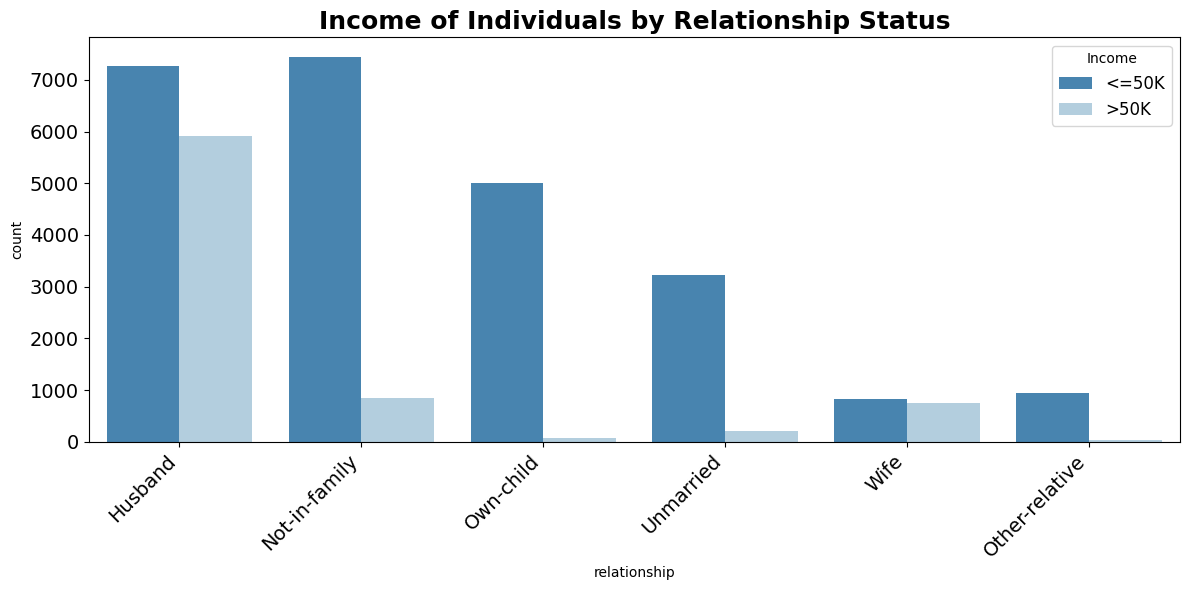

In [24]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='relationship', hue='income', palette='Blues_r',
              order=df['relationship'].value_counts().index)

plt.title('Income of Individuals by Relationship Status', fontsize=18, fontweight='bold')
plt.xticks(fontsize=14, rotation=45, ha='right')
plt.yticks(fontsize=14)
plt.legend(fontsize=12, title="Income")
plt.tight_layout()
plt.show()

**Observation:** A few things stand out from this plot:

**Wives** show a fairly even split between earning above and below 50K.
**Husbands** also show a meaningful share earning above 50K, though the majority still fall below that mark.
Individuals classified as **Unmarried** are overwhelmingly in the <=50K group, with very few crossing the 50K threshold.

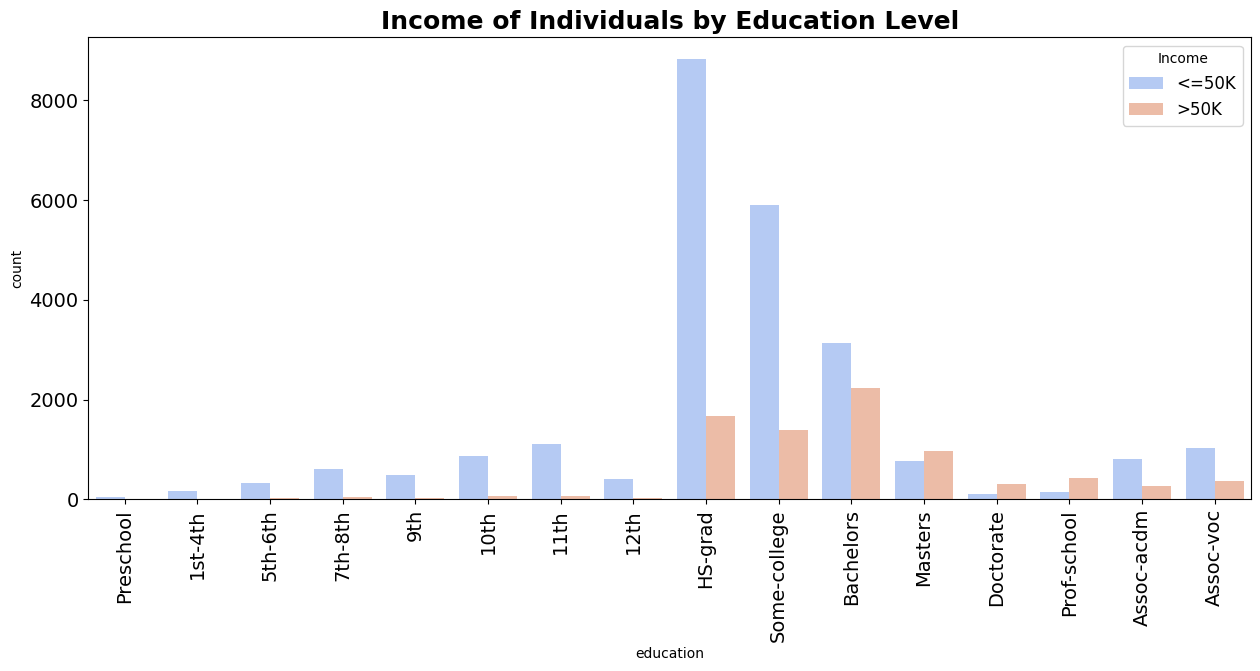

In [25]:
order_list = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
              'HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Doctorate', 'Prof-school',
              'Assoc-acdm', 'Assoc-voc']

plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='education', hue='income', palette='coolwarm', order=order_list)
plt.title('Income of Individuals by Education Level', fontsize=18, fontweight='bold')
plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14)
plt.legend(fontsize=12, title="Income")
plt.show()

**Observation**: This plot reveals some clear patterns by education level:

Individuals with education up to **12th grade** are overwhelmingly in the <=50K group, with very few earning above it.
For **Bachelors, Masters, Doctorate, and Prof-school holders**, the share earning >50K is notably higher, in several cases outnumbering those earning <=50K.
**Assoc-acdm and Assoc-voc holders** show only a small number earning above $50K, sitting between the lower and higher education groups.

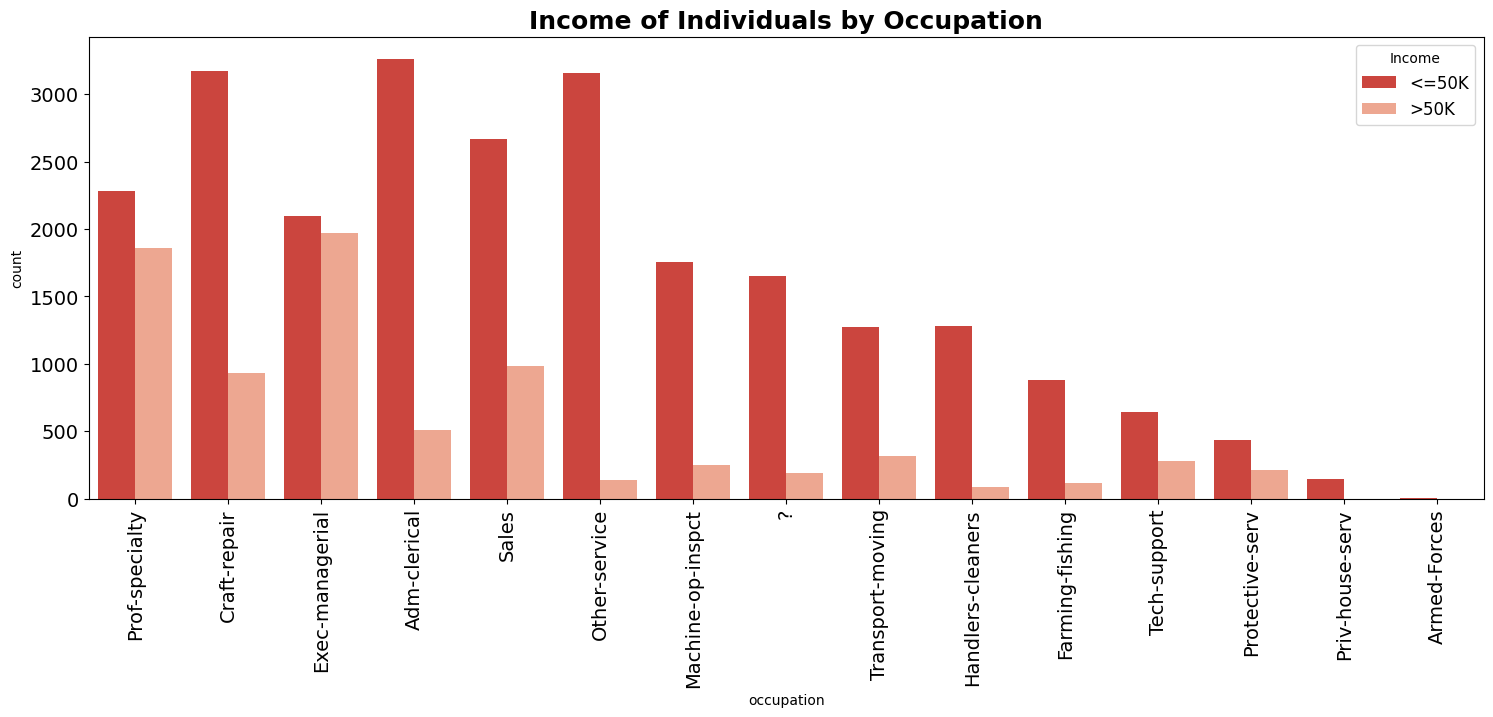

In [26]:
plt.figure(figsize=(18, 6))
sns.countplot(data=df, x='occupation', hue='income', palette='Reds_r',
              order=df['occupation'].value_counts().index)
plt.title('Income of Individuals by Occupation', fontsize=18, fontweight='bold')
plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14)
plt.legend(fontsize=12, title="Income")
plt.show()

**Observation**: Looking at occupation against income:

**Exec-managerial** roles show a fairly balanced split between the two income groups.
**Prof-specialty** roles show roughly a third of individuals earning above 50K.
Occupations like **Farming-fishing, Machine-op-inspct, Other-service, Adm-clerical, and Transport-moving** are dominated by the <=50K group, with very few earning above it.
**Sales roles** fall somewhere in between, with around a quarter earning above 50K.

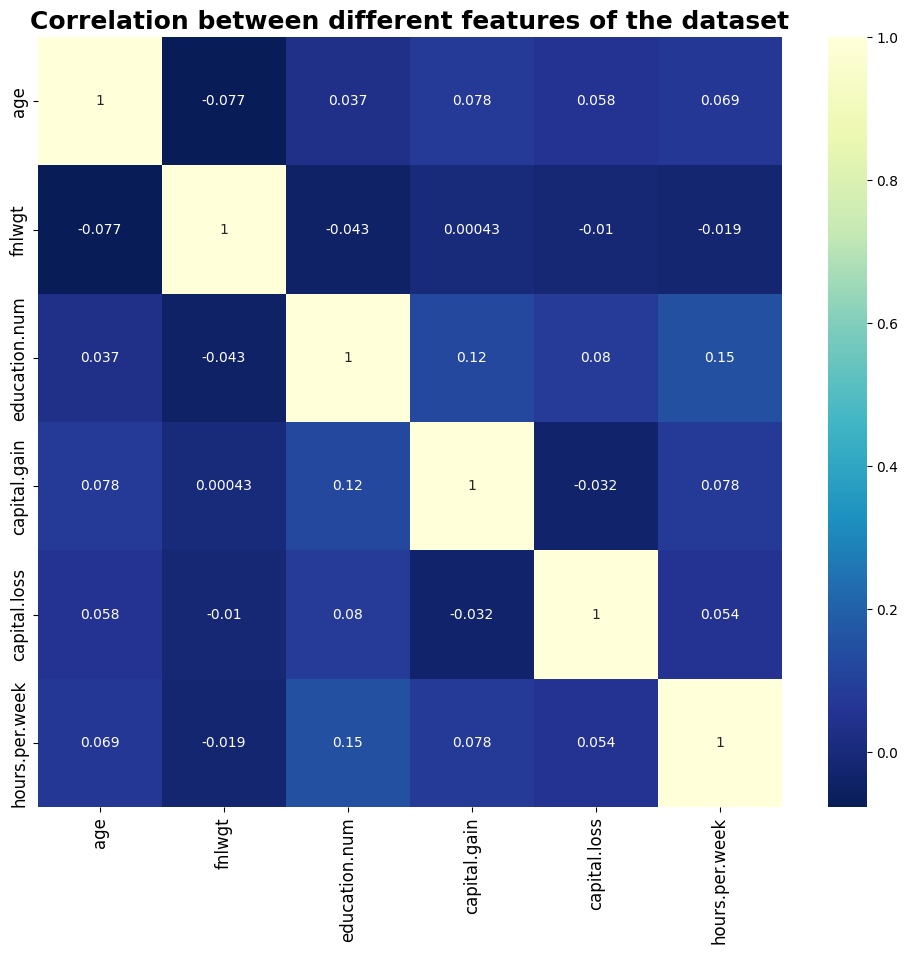

In [27]:
plt.figure(figsize=(12, 10))
plt.title("Correlation between different features of the dataset", fontsize=18, fontweight='bold')
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="YlGnBu_r", annot=True)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12, rotation=90)
plt.show()

**Observation**:This heatmap checks whether the numeric features show any relationship with each other and with income:

Most numeric features show a positive, though generally weak, correlation with income.
Categorical (object-type) columns aren't included here, since correlation only applies to numeric data; those relationships were explored separately through the countplots above.

#### 4. Clean the data, justifying every step in markdown. No blanket fillna . If you drop rows, explain why.

In [28]:
# Convert placeholder "?" to real NaN
df[df == "?"] = np.nan

# Impute missing values with mode (categorical columns)
imputer = SimpleImputer(strategy="most_frequent")
df[["workclass", "occupation", "native.country"]] = imputer.fit_transform(
    df[["workclass", "occupation", "native.country"]]
)

# Drop duplicate rows (24 identified during EDA)
df = df.drop_duplicates()

# Drop redundant education column (education.num already the numeric equivalent)
df = df.drop(columns=["education"])

 **Missing values (encoded as `?`)**

Here, we first checked for missing values using `.isnull().sum()`, but it showed no missing values. After checking the dataset more closely, we found that some missing values were represented using `"?"` instead of the usual `NaN`. These values were found in the `workclass`, `occupation`, and `native.country` columns, so we converted them to `NaN` to make them easier to identify and handle.

```python
df[df == "?"] = np.nan
```

**Imputing missing values**

After converting the `"?"` values to `NaN`, we found that `workclass`, `occupation`, and `native.country` had some missing values. Since these are categorical features and the percentage of missing values was relatively small, we decided to fill them using the most frequent category rather than dropping the affected rows. This allows us to keep as much of the original data as possible.

```python
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

df[["workclass", "occupation", "native.country"]] = imputer.fit_transform(
    df[["workclass", "occupation", "native.country"]]
)
```

**Dropping duplicate rows**

We also checked for duplicate rows and found 24 duplicates. Since these rows were identical across all columns, including `fnlwgt`, we treated them as duplicate records rather than separate observations. We therefore removed them from the dataset. This reduced the dataset from 32,561 rows to 32,537 rows, which is only about 0.07% of the data.

```python
df = df.drop_duplicates()
```

**Dropping the redundant `education` column**

The dataset contains both `education` and `education.num`. Since `education.num` already represents the education levels numerically, we decided to remove the original `education` column and keep `education.num`. This prevents us from keeping two columns that are essentially representing the same information in different forms.

```python
df = df.drop(columns=["education"])
```


In [29]:
df.head()

,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


**Observation:** We can now see that there is no longer an education section and that the missing values have been filled

## Part 2. Feature Engineering and Encoding

#### 1. Create at least three new features (for example: bin a continuous column, count occurrences per row, take a ratio, or build an interaction term). Each needs a markdown cell explaining the business reasoning

In [30]:
 #Feature One
 df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 40, 50, 60, 70, float("inf")],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70", "70+"]
)

**Reasoning**: I created an `age-group` column which will allow us in turn to group individuals in our data set into different age ranges which can reveal patterns we probably wouldn't have seen with individual ages that are specific to a particular age group

In [31]:
#Feature Two
df["has_capital_activity"] = (
    (df["capital.gain"] > 0) |
    (df["capital.loss"] > 0)
).astype(int)

**Reasoning:** I created a has_capital_activity feature to be able to tell apart individuals that have any capital-related financial activity from those individuals that have none. Since we're trying to predict income, this could give the model additional information about a person's financial situation beyond things like their age, education, and occupation.

In [32]:
#Feature Three
df["net_capital"] = df["capital.gain"] - df["capital.loss"]

**Reasoning:** The dataset gives us capital-gain and capital-loss as two separate features. I created net_capital to combine these into a single measure by subtracting the loss from the gain, I get one value that represents the person's overall capital position. Since we're predicting income, this could give the model additional information about the person's financial situation

In [33]:
#Feature Four
df["is_full_time"] = (df["hours.per.week"] >= 35).astype(int)

**Reasoning:** I created an `is_full_time` feature to distinguish individuals who work a full-time level of hours from those who work fewer hours per week. Since the target variable is income level, the amount of time an individual spends working may provide useful information about their earning potential

 #### 2. Encode every categorical column, choosing label or one-hot for each and justifying it. Use drop_first where appropriate and say why.

In [34]:
# Label/ordinal encoded
age_map = {"18-30": 0, "31-40": 1, "41-50": 2, "51-60": 3, "61-70": 4, "70+": 5}
df["age_group_encoded"] = df["age_group"].map(age_map).astype(float)
df = df.drop(columns=["age_group"])

**Reasoning:** `age_group` has a natural order because the categories go from younger age groups to older age groups. Because of this, we decided to represent the categories using a manual numeric mapping instead of one-hot encoding them. This keeps the order between the age groups, so the model can recognize that nearby age groups are more similar than groups that are further apart. The original `age_group` column was then removed after creating the numerical version.

In [35]:
# native.country sparsity reduction before encoding
country_counts = df["native.country"].value_counts()
rare_countries = country_counts[country_counts < 100].index
df["native.country"] = df["native.country"].replace(rare_countries, "Other")

**Reasoning:** `native.country` contains over 40 different countries, but some of the countries have very few observations. To avoid creating too many columns for categories with only a small number of records, we grouped countries with fewer than 100 occurrences into an `"Other"` category. This gives us a more manageable feature while still keeping the information about whether someone belongs to a less common country group. It also reduces the chance of very rare categories causing problems when the data is later split into training and test sets.

In [36]:
# Remaining nominal columns (one-hot encoded)
categorical_features = [
    "workclass", "marital.status", "occupation",
    "relationship", "race", "sex", "native.country"
]

one_hot = OneHotEncoder(drop="first", handle_unknown="ignore")

**Reasoning:** The categories in workclass, marital.status, occupation, relationship, race, sex, and native.country do not have a natural order. Because of this, we used one-hot encoding instead of assigning numbers to the categories. Assigning numbers would make the model treat one category as being higher or lower than another when there is no such relationship.

We also used drop="first" to remove one category from each feature. The remaining categories can then be compared against that dropped category, while also reducing the number of columns created by the encoding.

#### 3. Scale the features, choosing between StandardScaler and MinMaxScaler , and justify the choice.


In [37]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    "age", "fnlwgt", "education.num", "capital.gain",
    "capital.loss", "hours.per.week", "net_capital", "age_group_encoded"
]

**Reasoning:** We chose `StandardScaler` to put the numerical features on a similar scale before applying K-Means. Some of the features, such as `capital.gain`, `capital.loss`, and `fnlwgt`, have much larger ranges than others, so without scaling they could have a much bigger influence on the distance calculations used by K-Means.

`StandardScaler` transforms the numerical features so that they are centered around 0 with a standard deviation of 1. This makes the features more comparable and prevents features with larger numerical values from dominating the clustering results. We chose this approach because K-Means relies on distances between observations, making feature scaling particularly important for Part 3.

In [38]:
# Combined encoding + scaling, applied together so df stays unmodified:
preprocessor = ColumnTransformer(
    transformers=[
        ("one_hot", one_hot, categorical_features),
        ("scale", StandardScaler(), numerical_features)
    ],
    remainder="passthrough",
    sparse_threshold=0
)

X_encoded = preprocessor.fit_transform(df.drop(columns="income"))
print(X_encoded.shape)

(32537, 54)


## Part 3. Clustering Analysis

#### 1. Run K-Means for K from 2 to 10. Plot the elbow curve and the silhouette scores.


In [39]:

inertias = []
silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_encoded)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_encoded, km.labels_))

print("Inertias:", inertias)
print("Silhouette scores:", silhouette_scores)

Inertias: [303251.9153654547, 254142.36718088662, 222869.93328646373, 205150.33239754807, 193178.8893504729, 183338.72808227388, 175465.48847905535, 169934.65390556265, 164891.34170928778]
Silhouette scores: [np.float64(0.7884581025098479), np.float64(0.16990834580676203), np.float64(0.1868129184782208), np.float64(0.1357470319394677), np.float64(0.13434752909089515), np.float64(0.1330474743853797), np.float64(0.12031256754995454), np.float64(0.11552779517554336), np.float64(0.11986455241885373)]


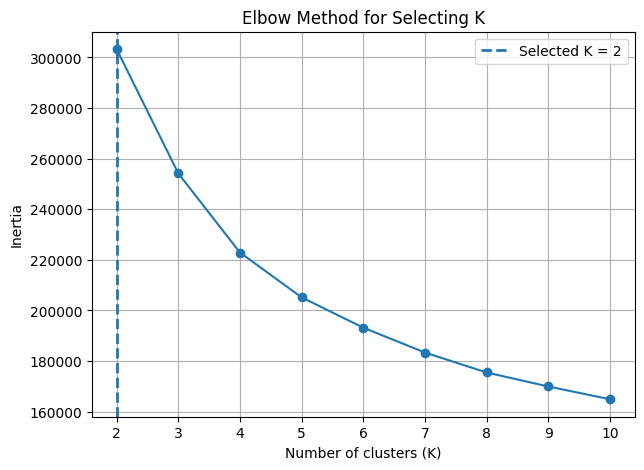

In [40]:
# Elbow Plot

plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 11),
    inertias,
    marker="o"
)

# Show selected K
plt.axvline(
    x=2,
    linestyle="--",
    linewidth=2,
    label="Selected K = 2"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(True)

plt.show()

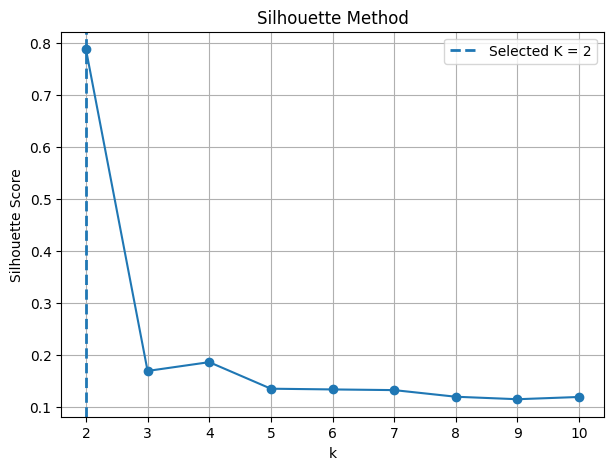

In [41]:
# Silhouette plot

plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

# Show selected K
plt.axvline(
    x=2,
    linestyle='--',
    linewidth=2,
    label='Selected K = 2'
)

plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(True)

plt.show()

#### 2. Pick a final K and justify it using both signals.

**Justification:** The silhouette score was highest at K=2 (0.788), indicating the clearest separation between the two clusters. The elbow curve also showed a substantial reduction in inertia from K=2 to K=3, followed by progressively smaller reductions. Considering both the silhouette score and the elbow curve, K=2 was selected for the final clustering.

#### 3. Profile each cluster with group means and give it a plain-English name (e.g. "long-tenure budgetcustomers").

In [42]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans.fit(X_encoded)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [43]:
df_cluster = df.drop(columns=["income"]).copy()

df_cluster["Cluster"] = kmeans.labels_

cluster_profile = (
    df_cluster
    .select_dtypes(include=np.number)
    .groupby("Cluster")
    .mean()
    .T
)

cluster_profile

Cluster,0,1
age,38.547378,46.358491
fnlwgt,189765.192878,192968.886792
education.num,10.067886,12.918239
capital.gain,592.670424,99999.000000
capital.loss,87.797270,0.000000
hours.per.week,40.394373,49.798742
has_capital_activity,0.125764,1.000000
net_capital,504.873155,99999.000000
is_full_time,0.827970,0.949686
age_group_encoded,1.371765,2.069182


In [44]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["marital.status"],
    normalize="index"
) * 100

marital.status,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed
Cluster,,,,,,,
0,13.682130,0.071036,45.827414,1.287912,32.908148,3.159553,3.063809
1,6.918239,0.000000,83.018868,0.628931,7.547170,1.257862,0.628931


In [45]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["occupation"],
    normalize="index"
) * 100

occupation,Adm-clerical,Armed-Forces,Craft-repair,Exec-managerial,Farming-fishing,Handlers-cleaners,Machine-op-inspct,Other-service,Priv-house-serv,Prof-specialty,Protective-serv,Sales,Tech-support,Transport-moving
Cluster,,,,,,,,,,,,,,
0,11.619001,0.027797,12.619680,12.425103,3.063809,4.225091,6.173945,10.158132,0.454012,18.246958,2.001359,11.195874,2.859967,4.929273
1,3.773585,0.000000,5.031447,26.415094,0.000000,0.628931,0.628931,1.257862,0.000000,44.654088,0.628931,15.723270,0.628931,0.628931


In [46]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["sex"],
    normalize="index"
) * 100

sex,Female,Male
Cluster,,
0,33.170671,66.829329
1,13.836478,86.163522


In [47]:
pd.crosstab(
    df_cluster["Cluster"],
    df_cluster["race"],
    normalize="index"
) * 100

race,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
Cluster,,,,,
0,0.960529,3.174995,9.620730,0.830811,85.412935
1,0.000000,6.289308,4.402516,1.257862,88.050314



The clusters were profiled using the mean values of the numerical features and the proportions of selected categorical characteristics.

* **Cluster 0 — Lower Capital-Activity Group:** This is the larger cluster, containing 32,378 individuals. Members have an average age of approximately 38.5 years, an average education level of 10.1, and work approximately 40.4 hours per week. About 82.8% are classified as full-time workers, while 12.6% have capital activity. Approximately 45.8% are married with a civilian spouse and 32.9% are never married. The cluster is 66.8% male and 33.2% female, with 85.4% identifying as White. Its occupational distribution is relatively broad, with notable representation in professional specialty, craft/repair, executive/managerial, sales, and administrative/clerical occupations.

* **Cluster 1 — Older, Highly Educated, High Capital-Activity Group:** This is a much smaller cluster, containing 159 individuals. Members have an average age of approximately 46.4 years, an average education level of 12.9, and work approximately 49.8 hours per week. About 95.0% are classified as full-time workers, and 100% have capital activity. Approximately 83.0% are married with a civilian spouse, while only 7.5% are never married. The cluster is predominantly male (86.2%) and White (88.1%). Professional specialty and executive/managerial occupations are particularly common, representing 44.7% and 26.4% of the cluster respectively. Because the cluster is small, this result should be interpreted as a descriptive pattern rather than evidence that cluster membership reliably predicts income.

Overall, the clustering separates the dataset into a large group characterized by relatively lower capital activity and a much smaller group distinguished by higher age, education, working hours, and capital activity. The smaller cluster also has a higher proportion of males and a greater concentration of professional and managerial occupations. These cluster names are descriptive summaries of the observed cluster characteristics and do not imply differences in income. The relationship between cluster membership and the income target is examined separately in Part 6.


**4. Visualize the clusters in two dimensions using PCA**

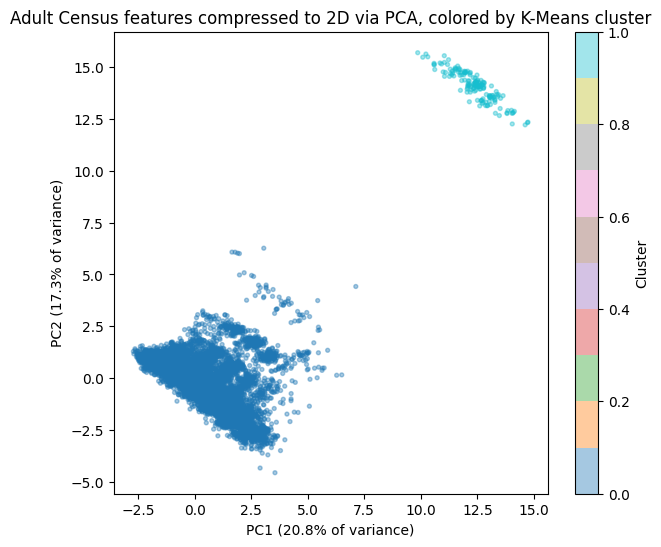

In [48]:


# Reduce to 2 components for visualization
pca2 = PCA(n_components=2, random_state=42)
proj = pca2.fit_transform(X_encoded)

plt.figure(figsize=(7, 6))

sc = plt.scatter(
    proj[:, 0],
    proj[:, 1],
    c=kmeans.labels_,
    cmap="tab10",
    alpha=0.4,
    s=8
)

plt.colorbar(sc, label="Cluster")

plt.xlabel(
    f"PC1 ({pca2.explained_variance_ratio_[0] * 100:.1f}% of variance)"
)

plt.ylabel(
    f"PC2 ({pca2.explained_variance_ratio_[1] * 100:.1f}% of variance)"
)

plt.title(
    "Adult Census features compressed to 2D via PCA, colored by K-Means cluster"
)

plt.show()

## Part 4. Classification

#### 1. Set up the task with train_test_split and stratify=y.

In [49]:

X = df.drop(columns="income")

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
categorical_features = [
    "workclass", "marital.status", "occupation",
    "relationship", "race", "sex", "native.country"
]
numerical_features = [
    "age", "fnlwgt", "education.num", "capital.gain",
    "capital.loss", "hours.per.week", "net_capital", "age_group_encoded"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("scale", StandardScaler(), numerical_features)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

#### 2. Train at least three classifiers from those covered in class, justifying each choice

In [51]:
models = {
    "Decision Tree (depth 4)": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN (k=5)": KNeighborsClassifier(
        n_neighbors=5
    )
}

for name, model in models.items():
    model.fit(X_train_encoded, y_train)
    print(f"{name} trained.")

Decision Tree (depth 4) trained.
Random Forest trained.
KNN (k=5) trained.


**Reasoning for Selection Of My Models**: I selected three different classification algorithms to compare how different approaches perform on the Adult Census Income dataset.

* **Decision Tree:** I chose Decision Tree as it can learn simple decision rules from the features and can capture non-linear relationships. It is also relatively easy to interpret, which makes it useful for understanding how features such as education, age, occupation, and hours worked can be used to classify income.

* **Random Forest:** I chose Random Forest because it combines multiple decision trees to produce a more robust model. It can capture non-linear relationships and interactions between features while reducing some of the overfitting that can occur with a single decision tree.

* **K-Nearest Neighbors (KNN):** I chose KNN because it makes predictions based on the similarity of observations in the feature space. This provides a different approach from the tree-based models and allows me to compare a distance-based classifier with the two tree-based classifiers.

Using these three models allows me to compare different classification approaches and evaluate their performance using the same test data and metrics.

#### 3. Report accuracy, precision, recall, F1, and ROC AUC for each, with a confusion matrix, and collect them in one comparison table (models in rows, metrics in columns).**

In [52]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_encoded)
    y_proba = model.predict_proba(X_test_encoded)[:, 1]  # probability of class 1 (>50K)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC AUC": auc
    })

    print(f"--- {name} ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()

results_df = pd.DataFrame(results).set_index("Model").round(2)

results_df

--- Decision Tree (depth 4) ---
Confusion Matrix:
[[4675  265]
 [ 763  805]]

--- Random Forest ---
Confusion Matrix:
[[4605  335]
 [ 603  965]]

--- KNN (k=5) ---
Confusion Matrix:
[[4473  467]
 [ 604  964]]



,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Decision Tree (depth 4),0.84,0.75,0.51,0.61,0.86
Random Forest,0.86,0.74,0.62,0.67,0.90
KNN (k=5),0.84,0.67,0.61,0.64,0.86


My Random Forest Classifier Had the Highest Metrics of the three Models

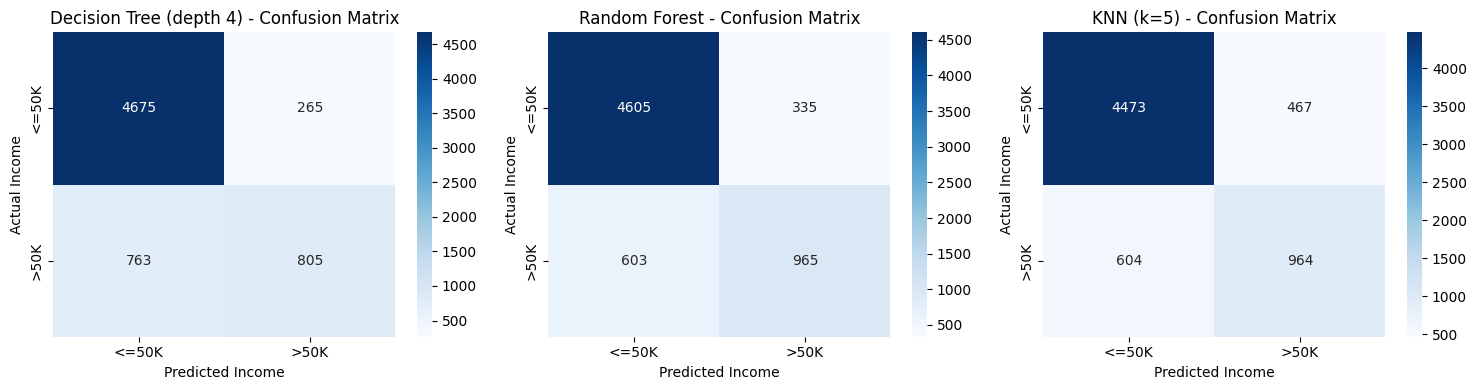

In [53]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_encoded)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
        ax=ax
    )

    ax.set_xlabel("Predicted Income")
    ax.set_ylabel("Actual Income")
    ax.set_title(f"{name} - Confusion Matrix")

plt.tight_layout()
plt.show()

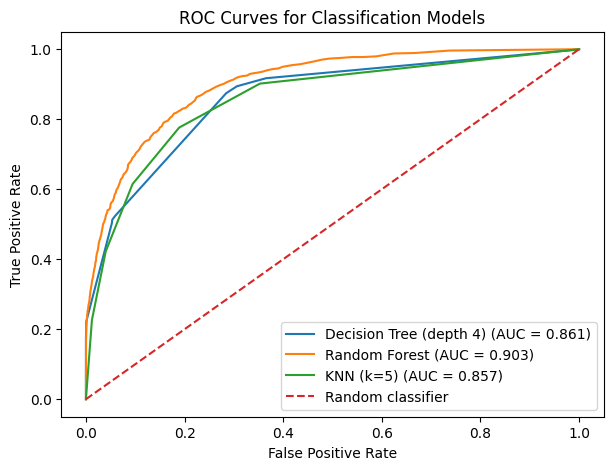

In [54]:
#Personal Addition
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

for name, model in models.items():
    y_proba = model.predict_proba(X_test_encoded)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend()
plt.show()

 #### 4. If your dataset has fewer than 2,000 rows, use stratified k-fold cross-validation instead of a single splitand report the mean and standard deviation of each metric.

Doesn't apply to my data set

## Part 5. Imbalance Handling

We selected the Random Forest model as the baseline for imbalance handling because it provided the strongest overall performance among the classifiers evaluated in the classification stage. The baseline is then compared with class weighting and threshold tuning to determine whether these techniques improve performance on the minority class.

In [55]:
# Use the selected Random Forest as the baseline for imbalance handling

pred_baseline = models["Random Forest"].predict(X_test_encoded)

print("Baseline Random Forest")
print("Accuracy:", round(accuracy_score(y_test, pred_baseline), 4))
print("Precision:", round(precision_score(y_test, pred_baseline), 4))
print("Recall:", round(recall_score(y_test, pred_baseline), 4))
print("F1:", round(f1_score(y_test, pred_baseline), 4))

Baseline Random Forest
Accuracy: 0.8559
Precision: 0.7423
Recall: 0.6154
F1: 0.6729


#### 1.Apply at least two of: class weights, threshold tuning, SMOTE

In [56]:
# Class weights
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_balanced.fit(X_train_encoded, y_train)

pred_balanced = rf_balanced.predict(X_test_encoded)

pred_baseline = models["Random Forest"].predict(X_test_encoded)

print(
    "no weighting - accuracy", round(accuracy_score(y_test, pred_baseline), 4),
    "f1", round(f1_score(y_test, pred_baseline), 4),
    "recall", round(recall_score(y_test, pred_baseline), 4)
)

print(
    "balanced - accuracy", round(accuracy_score(y_test, pred_balanced), 4),
    "f1", round(f1_score(y_test, pred_balanced), 4),
    "recall", round(recall_score(y_test, pred_balanced), 4)
)

no weighting - accuracy 0.8559 f1 0.6729 recall 0.6154
balanced - accuracy 0.854 f1 0.6669 recall 0.6065


In [57]:
 #Threshold tuning
prec, rec, thresh = precision_recall_curve(y_test, rf_balanced.predict_proba(X_test_encoded)[:, 1])

f1_scores = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = np.argmax(f1_scores[:-1])

print("best threshold:", round(thresh[best_idx], 3))
print("f1 at that threshold       :", round(f1_scores[best_idx], 4))
print("precision at that threshold:", round(prec[best_idx], 4))
print("recall at that threshold   :", round(rec[best_idx], 4))
print()
print("f1 at the default 0.5 threshold:", round(f1_score(y_test, (rf_balanced.predict_proba(X_test_encoded)[:, 1] >= 0.5).astype(int)), 4))

best threshold: 0.34
f1 at that threshold       : 0.6999
precision at that threshold: 0.6536
recall at that threshold   : 0.7532

f1 at the default 0.5 threshold: 0.669


#### 2. For threshold tuning, plot the precision-recall curve and pick a threshold tied to a stated business cost.


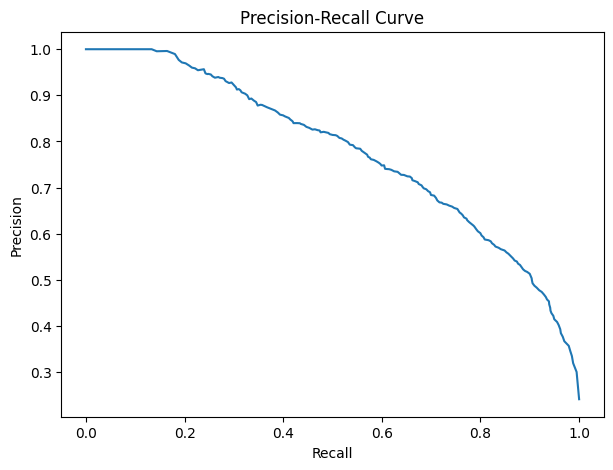

In [58]:
from sklearn.metrics import precision_recall_curve

proba = rf_balanced.predict_proba(X_test_encoded)[:, 1]

prec, rec, thresh = precision_recall_curve(y_test, proba)

plt.figure(figsize=(7, 5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [59]:
f1_scores = 2 * prec * rec / (prec + rec + 1e-12)

best_idx = np.argmax(f1_scores[:-1])

best_threshold = thresh[best_idx]

print("best threshold:", round(best_threshold, 3))
print("f1 at that threshold:", round(f1_scores[best_idx], 4))
print("precision at that threshold:", round(prec[best_idx], 4))
print("recall at that threshold:", round(rec[best_idx], 4))
threshold_pred = (proba >= best_threshold).astype(int)

best threshold: 0.34
f1 at that threshold: 0.6999
precision at that threshold: 0.6536
recall at that threshold: 0.7532


#### 3. Show a table of baseline versus each technique. If your dataset is roughly balanced (40 to 60 percent positive), still apply the techniques, but show with numbers that they change little and explain why. You are graded on the reasoning

We selected the Random Forest model as the baseline for imbalance handling because it provided the strongest overall performance among the classifiers evaluated in the classification stage. The baseline is then compared with class weighting and threshold tuning to determine whether these techniques improve performance on the minority class.

In [60]:

imbalance_results = [
    {
        "Technique": "Baseline",
        "Accuracy": accuracy_score(y_test, pred_baseline),
        "Precision": precision_score(y_test, pred_baseline),
        "Recall": recall_score(y_test, pred_baseline),
        "F1": f1_score(y_test, pred_baseline)
    },
    {
        "Technique": "Class Weights",
        "Accuracy": accuracy_score(y_test, pred_balanced),
        "Precision": precision_score(y_test, pred_balanced),
        "Recall": recall_score(y_test, pred_balanced),
        "F1": f1_score(y_test, pred_balanced)
    },
    {
        "Technique": "Threshold Tuning",
        "Accuracy": accuracy_score(y_test, threshold_pred),
        "Precision": precision_score(y_test, threshold_pred),
        "Recall": recall_score(y_test, threshold_pred),
        "F1": f1_score(y_test, threshold_pred)
    }
]

imbalance_results_df = (
    pd.DataFrame(imbalance_results)
    .set_index("Technique")
    .round(2)
)

imbalance_results_df

,Accuracy,Precision,Recall,F1
Technique,,,,
Baseline,0.86,0.74,0.62,0.67
Class Weights,0.85,0.74,0.61,0.67
Threshold Tuning,0.84,0.65,0.75,0.70


**Imbalance Handling Interpretation**

The target variable is imbalanced, with the `>50K` class representing approximately 24% of the observations. Therefore, imbalance-handling techniques were applied to examine whether they could improve detection of the minority class.

Class weighting produced very little change compared with the baseline Random Forest. Accuracy decreased slightly from 0.86 to 0.85, while precision remained at approximately 0.74, recall decreased from 0.62 to 0.61, and F1 remained at 0.67. This suggests that giving greater weight to the minority class did not substantially improve the model's ability to identify `>50K` observations in this case.

Threshold tuning produced a more noticeable change. Lowering the classification threshold to approximately 0.34 increased recall from 0.62 to 0.75 and F1 from 0.67 to 0.70. However, precision decreased from 0.74 to 0.65, while accuracy decreased from 0.86 to 0.84. This is consistent with lowering the threshold: the model becomes more willing to classify observations as `>50K`, resulting in more true positive cases being detected but also more false positives.

Overall, the results show that class weighting had little effect, whereas threshold tuning changed the precision-recall trade-off more substantially. For this analysis, I treated recall of the >50K class as an important objective, so I explored whether lowering the threshold could identify more positive cases.


## Part 6. The Tie-In

#### 1. Compute the positive-class rate within each K-Means cluster from Part 3.


In [61]:
# Calculate the positive-class rate (>50K) within each cluster
cluster_target_rate = (
    df.assign(Cluster=kmeans.labels_)
      .groupby("Cluster")["income"]
      .apply(lambda x: (x == ">50K").mean() * 100)
      .reset_index(name="Positive Class Rate (%)")
)

print(cluster_target_rate)

   Cluster  Positive Class Rate (%)
0        0                 23.71981
1        1                100.00000


#### 2. Were any clusters strong predictors of the label? Explain what that tells you about the data

The positive-class rate was calculated within each K-Means cluster to examine whether the unsupervised clusters were associated with the income target.

Cluster 0 has a `>50K` rate of **23.72%**, while Cluster 1 has a rate of **100.00%**. This shows a substantial difference in the target distribution between the two clusters. In particular, all observations assigned to Cluster 1 belong to the `>50K` class, whereas Cluster 0 has a positive-class rate close to the overall dataset rate.

These results suggest that the K-Means clustering has captured a group with characteristics strongly associated with the positive income class. The relationship between the clusters and income will therefore be considered when interpreting what the clustering analysis adds beyond the supervised classification models.


## Part 7. Conclusion and Recommendations

### 7.1 Submission Summary

**Model to deploy:** The Random Forest model with threshold tuning would be the model I would deploy. The baseline Random Forest achieved an F1 score of 0.67 and recall of 0.62, while the threshold-tuned model increased recall to 0.75 and F1 to 0.70. Although precision decreased from 0.74 to 0.65 and accuracy decreased from 0.86 to 0.84, the higher recall means the model identifies more of the `>50K` cases. Since detecting more positive cases is important for this task, this trade-off is reasonable.

**What I would do with another month of data:** I would retrain the model using the additional month of data and examine whether the new information improves prediction. I would also perform **hyperparameter tuning and further model fine-tuning** to determine whether the Random Forest can achieve better performance without sacrificing the recall that was gained through threshold tuning. I would then compare the tuned model with the current model using the same evaluation metrics before deciding whether to deploy the updated version.

**What the clusters revealed that the classifier did not directly show:** The clustering analysis revealed a distinct subgroup with a very different income distribution. Cluster 0 had a `>50K` rate of 23.72%, while Cluster 1 had a 100% positive-class rate. Income was not included when creating the clusters, so this relationship was discovered after the unsupervised clustering. This shows that the feature patterns used by K-Means naturally formed a small group that was entirely associated with the positive income class, providing an additional structural view of the dataset beyond the supervised classification metrics.

**Hardest team decision:** The hardest decision was determining how to handle the class imbalance and choose the appropriate classification threshold. Class weighting produced very little improvement, while lowering the threshold increased recall and F1 but reduced precision and accuracy. The team therefore had to decide whether identifying more `>50K` cases was worth accepting more false positives. The final threshold choice reflected the decision to place greater importance on identifying positive cases.


**Depth Track**


On top of the full pipeline, pick one track and go deeper. Draw conclusions from it, not just output.
Clustering: compare K-Means against hierarchical or DBSCAN (report agreement via crosstab or
adjusted Rand index), test stability on three 80% subsamples, and build three named personas with
representative rows.
Classification: train four or more classifiers with cross-validation, plot all ROC curves on one chart,
and compare feature importances across models.
Imbalance: apply all three techniques, plot precision-recall curves, and recommend a final operating
point with cost reasoning.






### D1. Classification Depth Track
To explore the classification problem further, I compared four different classification algorithms: Decision Tree, Random Forest, KNN, Logistic Regression. These models use different approaches to classification, allowing me to compare their performance and determine whether the results are consistent across different modelling techniques.

Decision Tree and Random Forest are tree-based models that make predictions by learning decision rules from the features. KNN classifies observations based on the similarity or distance between observations. Logistic Regression uses a linear relationship between the features to estimate the probability of belonging to a class.

In [62]:
from sklearn.linear_model import LogisticRegression
models_depth = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

D2. Stratified Cross-Validation

For this deeper analysis, I used 5-fold stratified cross-validation to evaluate how consistently each classifier performs across different subsets of the training data. Stratification was used to maintain a similar proportion of the two income classes in each fold.

The models were compared using accuracy, precision, recall, F1 score, and ROC AUC. F1 score and ROC AUC were given particular attention because the target variable is imbalanced and accuracy alone does not fully describe performance on the minority class

In [63]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in models_depth.items():

    scores = cross_validate(
        model,
        X_train_encoded,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.8444,0.7628,0.5138,0.6139,0.8727
1,Random Forest,0.8601,0.7499,0.6292,0.6842,0.9130
2,KNN,0.8373,0.6739,0.6297,0.6510,0.8660
3,Logistic Regression,0.8547,0.7433,0.6063,0.6678,0.9101


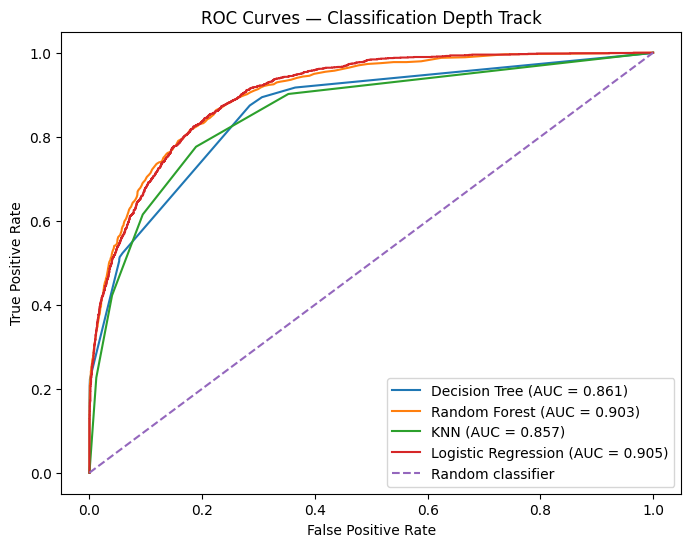

In [64]:
plt.figure(figsize=(8, 6))

for name, model in models_depth.items():

    model.fit(X_train_encoded, y_train)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_encoded)[:, 1]
    else:
        y_score = model.decision_function(X_test_encoded)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Depth Track")
plt.legend()
plt.show()

In [65]:
feature_names = preprocessor.get_feature_names_out()

rf_importances = pd.Series(
    models_depth["Random Forest"].feature_importances_, index=feature_names
).sort_values(ascending=False).head(10)

dt_importances = pd.Series(
    models_depth["Decision Tree"].feature_importances_, index=feature_names
).sort_values(ascending=False).head(10)

print("Random Forest top features:\n", rf_importances)
print("\nDecision Tree top features:\n", dt_importances)

Random Forest top features:
 scale__fnlwgt                                 0.152343
scale__age                                    0.118796
scale__education.num                          0.109249
one_hot__marital.status_Married-civ-spouse    0.078675
scale__net_capital                            0.075643
scale__hours.per.week                         0.072999
scale__capital.gain                           0.055914
scale__age_group_encoded                      0.041701
one_hot__marital.status_Never-married         0.034687
remainder__has_capital_activity               0.022807
dtype: float64

Decision Tree top features:
 one_hot__marital.status_Married-civ-spouse       0.491372
scale__education.num                             0.249901
scale__net_capital                               0.141200
scale__capital.gain                              0.106585
scale__capital.loss                              0.008233
scale__age                                       0.002709
one_hot__workclass_State-gov

**Feature Importance Comparison**

Feature importance was examined for the Random Forest and Decision Tree models to identify which transformed features contributed most to their predictions.

The Random Forest distributed importance across several features, with `fnlwgt`, `age`, `education.num`, married-civil-spouse status, `net_capital`, and `hours.per.week` among the most important. In contrast, the Decision Tree placed much greater importance on a smaller number of features, particularly `marital.status_Married-civ-spouse`, `education.num`, `net_capital`, and `capital.gain`.

This difference reflects how the two models make predictions. The Random Forest combines many decision trees, allowing importance to be distributed across features used by different trees, while the single Decision Tree can rely heavily on a few features that provide strong splits.

These importance values describe the features used by the models and should not be interpreted as evidence of causation.

 Dummy Classifier Baseline

To provide a baseline for the classification results, I compared the final Random Forest model with a stratified `DummyClassifier`. The dummy classifier does not learn meaningful relationships from the features; instead, it makes predictions based on the class distribution in the training data. This provides a useful benchmark to confirm that the final model performs better than a simple baseline.


In [66]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

dummy = DummyClassifier(
    strategy="stratified",
    random_state=42
)

dummy.fit(X_train_encoded, y_train)
dummy_pred = dummy.predict(X_test_encoded)
dummy_proba = dummy.predict_proba(X_test_encoded)[:, 1]

print("Dummy Classifier")
print("Accuracy :", round(accuracy_score(y_test, dummy_pred), 4))
print("Precision:", round(precision_score(y_test, dummy_pred), 4))
print("Recall   :", round(recall_score(y_test, dummy_pred), 4))
print("F1       :", round(f1_score(y_test, dummy_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, dummy_proba), 4))

Dummy Classifier
Accuracy : 0.6357
Precision: 0.2411
Recall   : 0.2385
F1       : 0.2398
ROC AUC  : 0.5001


In [67]:
final_proba = rf_balanced.predict_proba(X_test_encoded)[:, 1]

final_threshold = 0.34

final_pred = (
    final_proba >= final_threshold
).astype(int)

print("Final Random Forest")
print("Accuracy :", round(accuracy_score(y_test, final_pred), 4))
print("Precision:", round(precision_score(y_test, final_pred), 4))
print("Recall   :", round(recall_score(y_test, final_pred), 4))
print("F1       :", round(f1_score(y_test, final_pred), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, final_proba), 4))

Final Random Forest
Accuracy : 0.8443
Precision: 0.6536
Recall   : 0.7532
F1       : 0.6999
ROC AUC  : 0.9017


A probability threshold of 0.34 was selected for the final Random Forest model based on the threshold-tuning results. The default threshold of 0.50 requires a relatively high predicted probability before classifying an individual as >50K, which can result in more positive cases being missed. Lowering the threshold to 0.34 increases the model's ability to identify the positive class while maintaining a reasonable balance between precision and recall. This was particularly relevant because false negatives were considered more costly than false positives for this classification task. Therefore, the 0.34 threshold provides a practical operating point that places greater emphasis on detecting individuals belonging to the positive income class rather than relying on the default 0.50 cutoff.

In [68]:
dummy_row = {
    "Model": "Dummy Classifier (stratified)",
    "Accuracy": accuracy_score(y_test, dummy_pred),
    "Precision": precision_score(y_test, dummy_pred),
    "Recall": recall_score(y_test, dummy_pred),
    "F1": f1_score(y_test, dummy_pred),
    "ROC AUC": roc_auc_score(y_test, dummy_proba)
}

final_row = {
    "Model": "Final Random Forest (threshold=0.34)",
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred),
    "Recall": recall_score(y_test, final_pred),
    "F1": f1_score(y_test, final_pred),
    "ROC AUC": roc_auc_score(y_test, final_proba)
}

dummy_final_df = pd.DataFrame([
    dummy_row,
    final_row
])

(dummy_final_df.set_index("Model") * 100).round(2)

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Dummy Classifier (stratified),63.57,24.11,23.85,23.98,50.01
Final Random Forest (threshold=0.34),84.43,65.36,75.32,69.99,90.17


In [69]:
notebook_end_time = time.time()

total_time = notebook_end_time - notebook_start_time

print(f"Total notebook runtime: {total_time / 60:.2f} minutes")

Total notebook runtime: 12.22 minutes
